<a href="https://colab.research.google.com/github/bdsul/Synthetic-data_Audit/blob/main/Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Team-TUD/CTAB-GAN-Plus
import sys
sys.path.append('./CTAB-GAN-Plus')
from model.ctabgan import CTABGAN

Cloning into 'CTAB-GAN-Plus'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 77 (delta 21), reused 17 (delta 17), pack-reused 48 (from 1)
Receiving objects: 100% (77/77), 1.05 MiB | 3.42 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [2]:
pip install ucimlrepo

In [3]:
pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.9/206.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 10.2 MB/s eta 0:00:00


In [18]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sdv.metadata import SingleTableMetadata
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)

from sdv.evaluation.single_table import evaluate_quality

from model.ctabgan import CTABGAN

breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

cancer_data = pd.concat([X, y], axis=1)

target_col = cancer_data.columns[-1]

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(cancer_data)

scores = {
    "CTABGAN": [],
    "WGAN_GP": [],
    "CTGAN": [],
    "CopulaGAN": [],
    "TVAE": [],
    "GaussianCopula": []
}

N_RUNS = 10
N_SAMPLES = 1000

In [19]:
for seed in range(N_RUNS):

    print(f"\n================ RUN {seed+1}/{N_RUNS} ================")

    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # ---------------------------------------------------
    # CTABGAN
    # ---------------------------------------------------

    try:

        data_path = f"breast_cancer_seed_{seed}.csv"
        cancer_data.to_csv(data_path, index=False)

        ctabgan = CTABGAN(
            raw_csv_path=data_path,
            categorical_columns=[target_col],
            log_columns=[],
            mixed_columns={},
            integer_columns=[],
            problem_type={"Classification": target_col}
        )

        ctabgan.fit()

        synthetic_ctabgan = ctabgan.data_prep.inverse_prep(
            ctabgan.synthesizer.sample(N_SAMPLES)
        )

        quality = evaluate_quality(
            real_data=cancer_data,
            synthetic_data=synthetic_ctabgan,
            metadata=metadata
        )

        score = quality.get_score()

        scores["CTABGAN"].append(score)

        print("CTABGAN:", round(score,4))

    except Exception as e:
        print("CTABGAN Failed:", e)

    # ---------------------------------------------------
    # WGAN-GP
    # ---------------------------------------------------

    try:

        data_wgan = cancer_data.copy()

        encoder = LabelEncoder()

        data_wgan[target_col] = encoder.fit_transform(
            data_wgan[target_col]
        )

        scaler = StandardScaler()

        scaled_data = scaler.fit_transform(data_wgan)

        device = "cuda" if torch.cuda.is_available() else "cpu"

        real_tensor = torch.tensor(
            scaled_data,
            dtype=torch.float32
        ).to(device)

        batch_size = 64
        latent_dim = 64
        data_dim = real_tensor.shape[1]

        loader = torch.utils.data.DataLoader(
            real_tensor,
            batch_size=batch_size,
            shuffle=True,
            drop_last=True
        )

        class Generator(nn.Module):
            def __init__(self):
                super().__init__()

                self.model = nn.Sequential(
                    nn.Linear(latent_dim,128),
                    nn.BatchNorm1d(128),
                    nn.LeakyReLU(0.2),

                    nn.Linear(128,256),
                    nn.BatchNorm1d(256),
                    nn.LeakyReLU(0.2),

                    nn.Linear(256,data_dim)
                )

            def forward(self,z):
                return self.model(z)

        class Critic(nn.Module):
            def __init__(self):
                super().__init__()

                self.model = nn.Sequential(
                    nn.Linear(data_dim,256),
                    nn.LeakyReLU(0.2),

                    nn.Linear(256,128),
                    nn.LeakyReLU(0.2),

                    nn.Linear(128,1)
                )

            def forward(self,x):
                return self.model(x)

        generator = Generator().to(device)
        critic = Critic().to(device)

        optimizer_G = optim.Adam(
            generator.parameters(),
            lr=0.0001,
            betas=(0.5,0.9)
        )

        optimizer_C = optim.Adam(
            critic.parameters(),
            lr=0.0001,
            betas=(0.5,0.9)
        )

        def gradient_penalty(
            critic,
            real_samples,
            fake_samples
        ):

            alpha = torch.rand(
                real_samples.size(0),
                1,
                device=device
            )

            alpha = alpha.expand_as(real_samples)

            interpolates = (
                alpha * real_samples +
                (1-alpha) * fake_samples
            ).requires_grad_(True)

            critic_interpolates = critic(interpolates)

            gradients = torch.autograd.grad(
                outputs=critic_interpolates,
                inputs=interpolates,
                grad_outputs=torch.ones_like(
                    critic_interpolates
                ),
                create_graph=True,
                retain_graph=True
            )[0]

            gradients = gradients.view(
                gradients.size(0),
                -1
            )

            return (
                (gradients.norm(2,dim=1)-1)**2
            ).mean()

        for epoch in range(100):

            for real_batch in loader:

                real_batch = real_batch.to(device)

                for _ in range(5):

                    z = torch.randn(
                        real_batch.size(0),
                        latent_dim,
                        device=device
                    )

                    fake_batch = generator(z).detach()

                    critic_real = critic(
                        real_batch
                    ).mean()

                    critic_fake = critic(
                        fake_batch
                    ).mean()

                    gp = gradient_penalty(
                        critic,
                        real_batch,
                        fake_batch
                    )

                    critic_loss = (
                        critic_fake
                        - critic_real
                        + 10 * gp
                    )

                    optimizer_C.zero_grad()
                    critic_loss.backward()
                    optimizer_C.step()

                z = torch.randn(
                    real_batch.size(0),
                    latent_dim,
                    device=device
                )

                fake = generator(z)

                generator_loss = -critic(fake).mean()

                optimizer_G.zero_grad()
                generator_loss.backward()
                optimizer_G.step()

        with torch.no_grad():

            z = torch.randn(
                N_SAMPLES,
                latent_dim,
                device=device
            )

            synthetic_scaled = (
                generator(z)
                .cpu()
                .numpy()
            )

        synthetic = scaler.inverse_transform(
            synthetic_scaled
        )

        synthetic_wgan = pd.DataFrame(
            synthetic,
            columns=data_wgan.columns
        )

        synthetic_wgan[target_col] = (
            synthetic_wgan[target_col]
            .round()
            .clip(0,1)
            .astype(int)
        )

        synthetic_wgan[target_col] = (
            encoder.inverse_transform(
                synthetic_wgan[target_col]
            )
        )

        quality = evaluate_quality(
            real_data=cancer_data,
            synthetic_data=synthetic_wgan,
            metadata=metadata
        )

        score = quality.get_score()

        scores["WGAN_GP"].append(score)

        print("WGAN_GP:", round(score,4))

    except Exception as e:
        print("WGAN_GP Failed:", e)

    # ---------------------------------------------------
    # SDV MODELS
    # ---------------------------------------------------

    models = {
        "CTGAN": CTGANSynthesizer(metadata=metadata),
        "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
        "TVAE": TVAESynthesizer(metadata=metadata),
        "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
    }

    for model_name, model in models.items():

        try:

            model.fit(cancer_data)

            synthetic_data = model.sample(
                N_SAMPLES
            )

            quality = evaluate_quality(
                real_data=cancer_data,
                synthetic_data=synthetic_data,
                metadata=metadata
            )

            score = quality.get_score()

            scores[model_name].append(score)

            print(
                model_name,
                ":",
                round(score,4)
            )

        except Exception as e:

            print(
                model_name,
                "Failed:",
                e
            )


================ RUN 1/10 ================


100%|██████████| 150/150 [01:05<00:00,  2.30it/s]


Finished training in 76.61969304084778  seconds.
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 434.81it/s]|
Column Shapes Score: 85.07%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 222.55it/s]|
Column Pair Trends Score: 77.93%

Overall Score (Average): 81.5%

CTABGAN: 0.815
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 532.45it/s]|
Column Shapes Score: 92.88%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 221.58it/s]|
Column Pair Trends Score: 92.45%

Overall Score (Average): 92.66%

WGAN_GP: 0.9266
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 288.44it/s]|
Column Shapes Score: 69.17%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 224.88it/s]|
Column Pair Trends Score: 63.63%

Overall Score (Average): 66.4%

CTGAN : 0.664
Generating report ...

(1/2) Evaluating Column Shapes: |██████

100%|██████████| 150/150 [01:04<00:00,  2.32it/s]


Finished training in 71.35410523414612  seconds.
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 450.99it/s]|
Column Shapes Score: 87.75%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 228.28it/s]|
Column Pair Trends Score: 79.76%

Overall Score (Average): 83.75%

CTABGAN: 0.8375
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 409.03it/s]|
Column Shapes Score: 92.49%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 214.98it/s]|
Column Pair Trends Score: 91.01%

Overall Score (Average): 91.75%

WGAN_GP: 0.9175
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 244.85it/s]|
Column Shapes Score: 71.63%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 217.28it/s]|
Column Pair Trends Score: 63.93%

Overall Score (Average): 67.78%

CTGAN : 0.6778
Generating report ...

(1/2) Evaluating Column Shapes: |██

...

Finished training in 69.9419858455658  seconds.
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 429.11it/s]|
Column Shapes Score: 86.36%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 215.49it/s]|
Column Pair Trends Score: 79.42%

Overall Score (Average): 82.89%

CTABGAN: 0.8289
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 528.16it/s]|
Column Shapes Score: 93.27%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 218.27it/s]|
Column Pair Trends Score: 92.39%

Overall Score (Average): 92.83%

WGAN_GP: 0.9283
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 302.74it/s]|
Column Shapes Score: 70.81%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 222.28it/s]|
Column Pair Trends Score: 64.12%

Overall Score (Average): 67.47%

CTGAN : 0.6747
Generating report ...

(1/2) Evaluating Column Shapes: |███

100%|██████████| 150/150 [01:03<00:00,  2.36it/s]


Finished training in 70.28726148605347  seconds.
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 424.52it/s]|
Column Shapes Score: 84.48%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 223.63it/s]|
Column Pair Trends Score: 78.03%

Overall Score (Average): 81.26%

CTABGAN: 0.8126
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 415.89it/s]|
Column Shapes Score: 94.13%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 188.19it/s]|
Column Pair Trends Score: 91.74%

Overall Score (Average): 92.93%

WGAN_GP: 0.9293
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 280.89it/s]|
Column Shapes Score: 74.19%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 190.46it/s]|
Column Pair Trends Score: 64.35%

Overall Score (Average): 69.27%

CTGAN : 0.6927
Generating report ...

(1/2) Evaluating Column Shapes: |██

100%|██████████| 150/150 [01:03<00:00,  2.37it/s]


Finished training in 69.27219009399414  seconds.
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 389.33it/s]|
Column Shapes Score: 85.28%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 227.53it/s]|
Column Pair Trends Score: 78.51%

Overall Score (Average): 81.9%

CTABGAN: 0.819
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 550.15it/s]|
Column Shapes Score: 92.94%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 225.45it/s]|
Column Pair Trends Score: 92.42%

Overall Score (Average): 92.68%

WGAN_GP: 0.9268
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 326.71it/s]|
Column Shapes Score: 76.69%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 218.61it/s]|
Column Pair Trends Score: 64.37%

Overall Score (Average): 70.53%

CTGAN : 0.7053
Generating report ...

(1/2) Evaluating Column Shapes: |████

In [20]:
summary = []

for model_name, values in scores.items():

    if len(values) == 0:
        continue

    mean_score = np.mean(values)
    std_score = np.std(values)

    summary.append([
        model_name,
        round(mean_score,4),
        round(std_score,4),
        f"{mean_score:.4f} ± {std_score:.4f}"
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Generator",
        "Mean",
        "Std",
        "Mean ± Std"
    ]
)

summary_df = summary_df.sort_values(
    "Mean",
    ascending=False
).reset_index(drop=True)

display(summary_df)

,Generator,Mean,Std,Mean ± Std
0,GaussianCopula,0.9311,0.0000,0.9311 ± 0.0000
1,WGAN_GP,0.9261,0.0034,0.9261 ± 0.0034
2,TVAE,0.8700,0.0110,0.8700 ± 0.0110
3,CTABGAN,0.8084,0.0394,0.8084 ± 0.0394
4,CTGAN,0.6877,0.0147,0.6877 ± 0.0147
5,CopulaGAN,0.6703,0.0109,0.6703 ± 0.0109


In [4]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sdv.metadata import SingleTableMetadata
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)

from sdv.evaluation.single_table import (
    evaluate_quality,
    run_diagnostic
)

from model.ctabgan import CTABGAN

breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

data = pd.concat([X, y], axis=1)

target_col = "Diagnosis"

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

synthetic_datasets = {}
summary = []

data_path = "breast_cancer.csv"
data.to_csv(data_path, index=False)

ctabgan = CTABGAN(
    raw_csv_path=data_path,
    categorical_columns=[target_col],
    log_columns=[],
    mixed_columns={},
    integer_columns=[],
    problem_type={"Classification": target_col}
)

ctabgan.fit()

synthetic_ctabgan = ctabgan.data_prep.inverse_prep(
    ctabgan.synthesizer.sample(1000)
)

synthetic_datasets["CTABGAN"] = synthetic_ctabgan

diag = run_diagnostic(
    real_data=data,
    synthetic_data=synthetic_ctabgan,
    metadata=metadata
)

qual = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_ctabgan,
    metadata=metadata
)

summary.append(
    ("CTABGAN", diag.get_score(), qual.get_score())
)

data_wgan = data.copy()

label_encoder = LabelEncoder()
data_wgan[target_col] = label_encoder.fit_transform(data_wgan[target_col])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_wgan)

device = "cuda" if torch.cuda.is_available() else "cpu"

real_tensor = torch.tensor(
    scaled_data,
    dtype=torch.float32
).to(device)

batch_size = 64
latent_dim = 64
data_dim = real_tensor.shape[1]
epochs = 300
critic_iterations = 5
lambda_gp = 10

loader = torch.utils.data.DataLoader(
    real_tensor,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

class Generator(nn.Module):
    def __init__(self, latent_dim, data_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, data_dim)
        )

    def forward(self, z):
        return self.model(z)

class Critic(nn.Module):
    def __init__(self, data_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

generator = Generator(latent_dim, data_dim).to(device)
critic = Critic(data_dim).to(device)

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0001,
    betas=(0.5, 0.9)
)

optimizer_C = optim.Adam(
    critic.parameters(),
    lr=0.0001,
    betas=(0.5, 0.9)
)

def gradient_penalty(critic, real_samples, fake_samples):
    bs = real_samples.size(0)

    alpha = torch.rand(bs, 1, device=device).expand_as(real_samples)

    interpolates = (
        alpha * real_samples +
        (1 - alpha) * fake_samples
    ).requires_grad_(True)

    critic_interpolates = critic(interpolates)

    gradients = torch.autograd.grad(
        outputs=critic_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(critic_interpolates),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(bs, -1)

    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

for epoch in range(epochs):

    for real_batch in loader:

        real_batch = real_batch.to(device)

        for _ in range(critic_iterations):

            z = torch.randn(
                real_batch.size(0),
                latent_dim,
                device=device
            )

            fake_batch = generator(z).detach()

            critic_real = critic(real_batch).mean()
            critic_fake = critic(fake_batch).mean()

            gp = gradient_penalty(
                critic,
                real_batch,
                fake_batch
            )

            critic_loss = (
                critic_fake -
                critic_real +
                lambda_gp * gp
            )

            optimizer_C.zero_grad()
            critic_loss.backward()
            optimizer_C.step()

        z = torch.randn(
            real_batch.size(0),
            latent_dim,
            device=device
        )

        generated_batch = generator(z)

        generator_loss = -critic(generated_batch).mean()

        optimizer_G.zero_grad()
        generator_loss.backward()
        optimizer_G.step()

generator.eval()

with torch.no_grad():

    z = torch.randn(
        1000,
        latent_dim,
        device=device
    )

    synthetic_scaled = generator(z).cpu().numpy()

synthetic_array = scaler.inverse_transform(
    synthetic_scaled
)

synthetic_wgan = pd.DataFrame(
    synthetic_array,
    columns=data_wgan.columns
)

synthetic_wgan[target_col] = (
    synthetic_wgan[target_col]
    .round()
    .clip(0, 1)
    .astype(int)
)

synthetic_wgan[target_col] = label_encoder.inverse_transform(
    synthetic_wgan[target_col]
)

synthetic_datasets["WGAN_GP"] = synthetic_wgan

diag = run_diagnostic(
    real_data=data,
    synthetic_data=synthetic_wgan,
    metadata=metadata
)

qual = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_wgan,
    metadata=metadata
)

summary.append(
    ("WGAN_GP", diag.get_score(), qual.get_score())
)

models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

for name, model in models.items():

    model.fit(data)

    synthetic_data = model.sample(1000)

    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    quality_report = evaluate_quality(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    summary.append(
        (
            name,
            diagnostic_report.get_score(),
            quality_report.get_score()
        )
    )

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Model",
        "Diagnostic Score",
        "Quality Score"
    ]
)

summary_df = summary_df.sort_values(
    "Quality Score",
    ascending=False
).reset_index(drop=True)

display(summary_df)

best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]

display(best_synthetic_data.head())

100%|██████████| 150/150 [00:59<00:00,  2.51it/s]


Finished training in 80.73407912254333  seconds.
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 31/31 [00:00<00:00, 1684.72it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 221.17it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 419.64it/s]|
Column Shapes Score: 84.54%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:02<00:00, 229.61it/s]|
Column Pair Trends Score: 78.72%

Overall Score (Average): 81.63%

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 31/31 [00:00<00:00, 988.74it/s]|
Data Validity Score: 98.75%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 226.47it/s]|
Data Structure Score: 1.64%

Overall Score (Average): 50.19%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 442.49it/s]|
Column Shapes Score: 94.95%


,Model,Diagnostic Score,Quality Score
0,WGAN_GP,0.501939,0.941961
1,GaussianCopula,1.000000,0.931075
2,TVAE,1.000000,0.887418
3,CTABGAN,1.000000,0.816291
4,CopulaGAN,1.000000,0.675077
5,CTGAN,1.000000,0.662612


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,14.174870,20.237537,92.041924,702.863586,0.090496,0.091342,0.048762,0.038516,0.172852,0.058277,...,28.640509,112.874695,968.542725,0.136021,0.289949,0.277576,0.127843,0.292048,0.077074,B
1,15.190398,23.245901,97.036865,763.774963,0.099200,0.079377,0.087500,0.037988,0.168673,0.056506,...,32.056534,122.853180,1164.933716,0.135463,0.158129,0.283191,0.103779,0.255605,0.081796,B
2,17.402048,11.635321,114.203964,906.776794,0.110202,0.130750,0.129734,0.085704,0.204188,0.058402,...,12.779770,118.990929,750.496643,0.123798,0.158324,0.145191,0.133106,0.281883,0.061986,B
3,13.179212,17.757090,83.532990,541.883484,0.097784,0.083633,0.029060,0.030591,0.161741,0.059855,...,22.314220,99.487442,583.216919,0.129220,0.185294,0.105475,0.102516,0.236946,0.078276,B
4,11.495486,13.995139,71.932106,338.718536,0.107153,0.091044,0.050403,0.021688,0.193540,0.064203,...,19.093010,81.157570,506.686035,0.149054,0.250173,0.205430,0.099303,0.293613,0.085168,B


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = {

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_models(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    # Split TRAIN df -> (train part only)  (we don’t need train_df's test split)
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    # Split TEST df -> (test part only)
    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    # Scale using TRAIN statistics only
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)

        y_pred = clf.predict(X_test_s)

        # AUC needs probabilities (or decision_function); handle both safely
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            # convert to 0-1-ish range (not perfect prob, but works for AUC)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, pos_label='M') # Explicitly set pos_label

        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan") # Removed pos_label for roc_auc_score

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

In [14]:
import pandas as pd

label_col = "Diagnosis"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula", "WGAN_GP", "CTABGAN"]

trtr_results = evaluate_models(
    train_df=data,
    test_df= data,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df= data,
        label_col=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (combined_comparison
           .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
           .mean()
           .sort_values("AUC_Drop"))

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)

TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.973684,0.962963,0.998843
0,LogReg,0.973684,0.963855,0.996032
7,GradientBoost,0.964912,0.950000,0.994709
1,SVM-RBF,0.973684,0.962963,0.994709
9,MLP,0.964912,0.950000,0.993717
5,RandomForest,0.973684,0.962963,0.992890
3,NaiveBayes,0.921053,0.888889,0.989087
8,AdaBoost,0.982456,0.975610,0.984127
2,KNN,0.956140,0.938272,0.982308
4,DecisionTree,0.929825,0.904762,0.924603


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1,AUC
5,RandomForest,0.789474,0.720930,0.878803
6,ExtraTrees,0.736842,0.705882,0.829861
7,GradientBoost,0.745614,0.694737,0.809524
2,KNN,0.710526,0.582278,0.781250
8,AdaBoost,0.640351,0.643478,0.753307
1,SVM-RBF,0.535088,0.495238,0.561839
9,MLP,0.535088,0.184615,0.561177
0,LogReg,0.429825,0.496124,0.458664
3,NaiveBayes,0.324561,0.429630,0.391865
4,DecisionTree,0.324561,0.330435,0.351190


CTGAN - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1,AUC
6,ExtraTrees,0.912281,0.871795,0.984954
5,RandomForest,0.929825,0.902439,0.984954
0,LogReg,0.885965,0.821918,0.980489
8,AdaBoost,0.912281,0.880952,0.969246
7,GradientBoost,0.885965,0.843373,0.960648
3,NaiveBayes,0.885965,0.831169,0.957341
9,MLP,0.921053,0.886076,0.952381
1,SVM-RBF,0.877193,0.820513,0.945106
2,KNN,0.903509,0.853333,0.930556
4,DecisionTree,0.842105,0.763158,0.810516


CTABGAN - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
9,DecisionTree,0.929825,0.904762,0.924603,0.842105,0.763158,0.810516,0.114087,0.141604,0.087719,CTABGAN
8,KNN,0.956140,0.938272,0.982308,0.903509,0.853333,0.930556,0.051753,0.084938,0.052632,CTABGAN
3,SVM-RBF,0.973684,0.962963,0.994709,0.877193,0.820513,0.945106,0.049603,0.142450,0.096491,CTABGAN
4,MLP,0.964912,0.950000,0.993717,0.921053,0.886076,0.952381,0.041336,0.063924,0.043860,CTABGAN
2,GradientBoost,0.964912,0.950000,0.994709,0.885965,0.843373,0.960648,0.034061,0.106627,0.078947,CTABGAN
6,NaiveBayes,0.921053,0.888889,0.989087,0.885965,0.831169,0.957341,0.031746,0.057720,0.035088,CTABGAN
1,LogReg,0.973684,0.963855,0.996032,0.885965,0.821918,0.980489,0.015542,0.141938,0.087719,CTABGAN
7,AdaBoost,0.982456,0.975610,0.984127,0.912281,0.880952,0.969246,0.014881,0.094657,0.070175,CTABGAN
0,ExtraTrees,0.973684,0.962963,0.998843,0.912281,0.871795,0.984954,0.013889,0.091168,0.061404,CTABGAN
5,RandomForest,0.973684,0.962963,0.992890,0.929825,0.902439,0.984954,0.007937,0.060524,0.043860,CTABGAN


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
5,WGAN_GP,0.000546
4,TVAE,0.001786
0,CTABGAN,0.037483
3,GaussianCopula,0.040691
2,CopulaGAN,0.261524
1,CTGAN,0.347354


In [25]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Re-define models to ensure it contains scikit-learn classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = {

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

# Assume cancer_data and target_col are already defined globally
X_real = cancer_data.drop(columns=[target_col])
y_real = cancer_data[target_col]

N_RUNS = 10 # Number of runs for evaluation, consistent with prior cells
TEST_SIZE = 0.3 # Test set size for train_test_split

# ----------------------------------------------------
# TRTR (Train Real, Test Real) Evaluation
# ----------------------------------------------------
print("--- Starting TRTR Evaluation (Train Real, Test Real) ---")
trtr_results = []

for model_name, model in models.items():

    accuracy_scores = []
    f1_scores = []
    precision_scores = []
    recall_scores = []

    print(f"  Running {model_name} for TRTR...")

    for seed in range(N_RUNS):

        X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
            X_real,
            y_real,
            test_size=TEST_SIZE,
            stratify=y_real,
            random_state=seed
        )

        clf = clone(model)

        if hasattr(clf, "random_state"):
            clf.set_params(random_state=seed)

        clf.fit(X_train_real, y_train_real)

        y_pred = clf.predict(X_test_real)

        accuracy_scores.append(accuracy_score(y_test_real, y_pred))
        f1_scores.append(f1_score(y_test_real, y_pred, average="weighted", zero_division=0))
        precision_scores.append(precision_score(y_test_real, y_pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test_real, y_pred, average="weighted", zero_division=0))

    trtr_results.append({
        "Model": model_name,
        "Accuracy Mean_TRTR": np.mean(accuracy_scores),
        "Accuracy Std_TRTR": np.std(accuracy_scores),
        "F1 Mean_TRTR": np.mean(f1_scores),
        "F1 Std_TRTR": np.std(f1_scores),
        "Precision Mean_TRTR": np.mean(precision_scores),
        "Precision Std_TRTR": np.std(precision_scores),
        "Recall Mean_TRTR": np.mean(recall_scores),
        "Recall Std_TRTR": np.std(recall_scores),
        "Accuracy (Mean±Std)_TRTR": f"{np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}",
        "F1 (Mean±Std)_TRTR": f"{np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}",
        "Precision (Mean±Std)_TRTR": f"{np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}",
        "Recall (Mean±Std)_TRTR": f"{np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}"
    })

trtr_results_df = pd.DataFrame(trtr_results)
display(trtr_results_df[
    [
        "Model",
        "Accuracy (Mean±Std)_TRTR",
        "F1 (Mean±Std)_TRTR",
        "Precision (Mean±Std)_TRTR",
        "Recall (Mean±Std)_TRTR"
    ]
])

# ----------------------------------------------------
# TSTR (Train Synthetic, Test Real) Evaluation
# ----------------------------------------------------
print("\n--- Starting TSTR Evaluation (Train Synthetic, Test Real) ---")
all_tstr_results = []

# Check if synthetic_datasets is available, otherwise skip TSTR
if 'synthetic_datasets' not in locals() and 'synthetic_datasets' not in globals():
    print("Warning: 'synthetic_datasets' variable not found. TSTR evaluation will be skipped.")
elif not synthetic_datasets:
    print("Warning: 'synthetic_datasets' is empty. TSTR evaluation will be skipped.")
else:
    for synth_data_name, synthetic_df in synthetic_datasets.items():
        print(f"\n  Evaluating TSTR for Synthetic Model: {synth_data_name}")

        X_synth = synthetic_df.drop(columns=[target_col])
        y_synth = synthetic_df[target_col]

        tstr_current_synth_results = []

        for model_name, model in models.items():
            accuracy_scores = []
            f1_scores = []
            precision_scores = []
            recall_scores = []

            print(f"    Running {model_name}...")

            for seed in range(N_RUNS):
                # Split the synthetic data to get a training portion for the classifier.
                X_train_synth_split, _, y_train_synth_split, _ = train_test_split(
                    X_synth, y_synth, test_size=TEST_SIZE, random_state=seed, stratify=y_synth
                )

                # Split the real data to get a test portion for the classifier.
                _, X_test_real_split, _, y_test_real_split = train_test_split(
                    X_real, y_real, test_size=TEST_SIZE, random_state=seed, stratify=y_real
                )

                clf = clone(model)

                if hasattr(clf, "random_state"):
                    clf.set_params(random_state=seed)

                clf.fit(X_train_synth_split, y_train_synth_split)

                y_pred = clf.predict(X_test_real_split)

                accuracy_scores.append(accuracy_score(y_test_real_split, y_pred))
                f1_scores.append(f1_score(y_test_real_split, y_pred, average="weighted", zero_division=0))
                precision_scores.append(precision_score(y_test_real_split, y_pred, average="weighted", zero_division=0))
                recall_scores.append(recall_score(y_test_real_split, y_pred, average="weighted", zero_division=0))

            tstr_current_synth_results.append({
                "Synthetic_Model": synth_data_name,
                "Model": model_name,
                "Accuracy Mean_TSTR": np.mean(accuracy_scores),
                "Accuracy Std_TSTR": np.std(accuracy_scores),
                "F1 Mean_TSTR": np.mean(f1_scores),
                "F1 Std_TSTR": np.std(f1_scores),
                "Precision Mean_TSTR": np.mean(precision_scores),
                "Precision Std_TSTR": np.std(precision_scores),
                "Recall Mean_TSTR": np.mean(recall_scores),
                "Recall Std_TSTR": np.std(recall_scores),
                "Accuracy (Mean±Std)_TSTR": f"{np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}",
                "F1 (Mean±Std)_TSTR": f"{np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}",
                "Precision (Mean±Std)_TSTR": f"{np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}",
                "Recall (Mean±Std)_TSTR": f"{np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}"
            })
        all_tstr_results.extend(tstr_current_synth_results)

    tstr_results_df = pd.DataFrame(all_tstr_results)
    display(tstr_results_df[
        [
            "Synthetic_Model",
            "Model",
            "Accuracy (Mean±Std)_TSTR",
            "F1 (Mean±Std)_TSTR",
            "Precision (Mean±Std)_TSTR",
            "Recall (Mean±Std)_TSTR"
        ]
    ])

    # ----------------------------------------------------
    # Combine and display results (TRTR vs TSTR Comparison)
    # ----------------------------------------------------
    print("\n--- Comparing TRTR vs TSTR Performance ---")
    combined_comparison_dfs = []

    # Iterate over each synthetic model to create a comparison with TRTR
    for synth_name in tstr_results_df["Synthetic_Model"].unique():
        tstr_subset = tstr_results_df[tstr_results_df["Synthetic_Model"] == synth_name]

        comparison = trtr_results_df.merge(
            tstr_subset, on="Model", suffixes=('_TRTR', '_TSTR')
        )

        # Calculate performance drops
        comparison["Accuracy_Drop"] = comparison["Accuracy Mean_TRTR"] - comparison["Accuracy Mean_TSTR"]
        comparison["F1_Drop"] = comparison["F1 Mean_TRTR"] - comparison["F1 Mean_TSTR"]
        comparison["Precision_Drop"] = comparison["Precision Mean_TRTR"] - comparison["Precision Mean_TSTR"]
        comparison["Recall_Drop"] = comparison["Recall Mean_TRTR"] - comparison["Recall Mean_TSTR"]

        comparison = comparison.sort_values("Accuracy_Drop", ascending=False)
        combined_comparison_dfs.append(comparison)

    final_comparison_df = pd.concat(combined_comparison_dfs, ignore_index=True)

    # Display summary of drops
    summary_drops = final_comparison_df.groupby("Synthetic_Model")[
        ["Accuracy_Drop", "F1_Drop", "Precision_Drop", "Recall_Drop"]
    ].mean().sort_values("Accuracy_Drop", ascending=True) # Lower drop is better

    print("\nAverage Performance Drop by Synthetic Generator (TRTR - TSTR, lower is better):")
    display(summary_drops)

    # Display the detailed final comparison dataframe
    print("\nDetailed TRTR vs TSTR Comparison:")
    display(final_comparison_df[
        [
            "Synthetic_Model",
            "Model",
            "Accuracy (Mean±Std)_TRTR",
            "Accuracy (Mean±Std)_TSTR",
            "Accuracy_Drop",
            "F1 (Mean±Std)_TRTR",
            "F1 (Mean±Std)_TSTR",
            "F1_Drop",
            "Precision (Mean±Std)_TRTR",
            "Precision (Mean±Std)_TSTR",
            "Precision_Drop",
            "Recall (Mean±Std)_TRTR",
            "Recall (Mean±Std)_TSTR",
            "Recall_Drop"
        ]
    ])


--- Starting TRTR Evaluation (Train Real, Test Real) ---
  Running LogReg for TRTR...
  Running SVM-RBF for TRTR...
  Running KNN for TRTR...
  Running NaiveBayes for TRTR...
  Running DecisionTree for TRTR...
  Running RandomForest for TRTR...
  Running ExtraTrees for TRTR...
  Running GradientBoost for TRTR...
  Running AdaBoost for TRTR...
  Running MLP for TRTR...


,Model,Accuracy (Mean±Std)_TRTR,F1 (Mean±Std)_TRTR,Precision (Mean±Std)_TRTR,Recall (Mean±Std)_TRTR
0,LogReg,0.9468 ± 0.0170,0.9466 ± 0.0171,0.9472 ± 0.0172,0.9468 ± 0.0170
1,SVM-RBF,0.9111 ± 0.0113,0.9090 ± 0.0118,0.9165 ± 0.0117,0.9111 ± 0.0113
2,KNN,0.9281 ± 0.0150,0.9276 ± 0.0151,0.9287 ± 0.0157,0.9281 ± 0.0150
3,NaiveBayes,0.9310 ± 0.0163,0.9303 ± 0.0164,0.9327 ± 0.0168,0.9310 ± 0.0163
4,DecisionTree,0.9158 ± 0.0266,0.9159 ± 0.0264,0.9168 ± 0.0260,0.9158 ± 0.0266
5,RandomForest,0.9491 ± 0.0187,0.9489 ± 0.0188,0.9496 ± 0.0185,0.9491 ± 0.0187
6,ExtraTrees,0.9538 ± 0.0149,0.9536 ± 0.0151,0.9541 ± 0.0147,0.9538 ± 0.0149
7,GradientBoost,0.9485 ± 0.0122,0.9483 ± 0.0123,0.9493 ± 0.0122,0.9485 ± 0.0122
8,AdaBoost,0.9515 ± 0.0148,0.9512 ± 0.0149,0.9520 ± 0.0146,0.9515 ± 0.0148
9,MLP,0.9392 ± 0.0162,0.9387 ± 0.0164,0.9403 ± 0.0160,0.9392 ± 0.0162



--- Starting TSTR Evaluation (Train Synthetic, Test Real) ---

  Evaluating TSTR for Synthetic Model: CTABGAN
    Running LogReg...
    Running SVM-RBF...
    Running KNN...
    Running NaiveBayes...
    Running DecisionTree...
    Running RandomForest...
    Running ExtraTrees...
    Running GradientBoost...
    Running AdaBoost...
    Running MLP...

  Evaluating TSTR for Synthetic Model: WGAN_GP
    Running LogReg...
    Running SVM-RBF...
    Running KNN...
    Running NaiveBayes...
    Running DecisionTree...
    Running RandomForest...
    Running ExtraTrees...
    Running GradientBoost...
    Running AdaBoost...
    Running MLP...

  Evaluating TSTR for Synthetic Model: CTGAN
    Running LogReg...
    Running SVM-RBF...
    Running KNN...
    Running NaiveBayes...
    Running DecisionTree...
    Running RandomForest...
    Running ExtraTrees...
    Running GradientBoost...
    Running AdaBoost...
    Running MLP...

  Evaluating TSTR for Synthetic Model: CopulaGAN
    Running L

,Synthetic_Model,Model,Accuracy (Mean±Std)_TSTR,F1 (Mean±Std)_TSTR,Precision (Mean±Std)_TSTR,Recall (Mean±Std)_TSTR
0,CTABGAN,LogReg,0.8977 ± 0.0131,0.8943 ± 0.0141,0.9063 ± 0.0120,0.8977 ± 0.0131
1,CTABGAN,SVM-RBF,0.8971 ± 0.0120,0.8938 ± 0.0124,0.9054 ± 0.0135,0.8971 ± 0.0120
2,CTABGAN,KNN,0.7825 ± 0.0226,0.7857 ± 0.0221,0.8074 ± 0.0195,0.7825 ± 0.0226
3,CTABGAN,NaiveBayes,0.8942 ± 0.0164,0.8910 ± 0.0175,0.9007 ± 0.0155,0.8942 ± 0.0164
4,CTABGAN,DecisionTree,0.7825 ± 0.0460,0.7843 ± 0.0451,0.7916 ± 0.0418,0.7825 ± 0.0460
5,CTABGAN,RandomForest,0.8988 ± 0.0155,0.8986 ± 0.0155,0.8993 ± 0.0157,0.8988 ± 0.0155
6,CTABGAN,ExtraTrees,0.9117 ± 0.0103,0.9112 ± 0.0104,0.9122 ± 0.0107,0.9117 ± 0.0103
7,CTABGAN,GradientBoost,0.8713 ± 0.0375,0.8722 ± 0.0368,0.8756 ± 0.0336,0.8713 ± 0.0375
8,CTABGAN,AdaBoost,0.8696 ± 0.0359,0.8707 ± 0.0350,0.8771 ± 0.0304,0.8696 ± 0.0359
9,CTABGAN,MLP,0.7901 ± 0.0380,0.7802 ± 0.0427,0.8152 ± 0.0208,0.7901 ± 0.0380



--- Comparing TRTR vs TSTR Performance ---

Average Performance Drop by Synthetic Generator (TRTR - TSTR, lower is better):


,Accuracy_Drop,F1_Drop,Precision_Drop,Recall_Drop
Synthetic_Model,,,,
TVAE,0.013099,0.013220,0.011088,0.013099
WGAN_GP,0.029298,0.032794,0.019146,0.029298
GaussianCopula,0.075614,0.082041,0.063288,0.075614
CTABGAN,0.077953,0.078805,0.069632,0.077953
CopulaGAN,0.310000,0.326818,0.281698,0.310000
CTGAN,0.355439,0.380656,0.356312,0.355439



Detailed TRTR vs TSTR Comparison:


,Synthetic_Model,Model,Accuracy (Mean±Std)_TRTR,Accuracy (Mean±Std)_TSTR,Accuracy_Drop,F1 (Mean±Std)_TRTR,F1 (Mean±Std)_TSTR,F1_Drop,Precision (Mean±Std)_TRTR,Precision (Mean±Std)_TSTR,Precision_Drop,Recall (Mean±Std)_TRTR,Recall (Mean±Std)_TSTR,Recall_Drop
0,CTABGAN,MLP,0.9392 ± 0.0162,0.7901 ± 0.0380,0.149123,0.9387 ± 0.0164,0.7802 ± 0.0427,0.158551,0.9403 ± 0.0160,0.8152 ± 0.0208,0.125075,0.9392 ± 0.0162,0.7901 ± 0.0380,0.149123
1,CTABGAN,KNN,0.9281 ± 0.0150,0.7825 ± 0.0226,0.145614,0.9276 ± 0.0151,0.7857 ± 0.0221,0.141915,0.9287 ± 0.0157,0.8074 ± 0.0195,0.121282,0.9281 ± 0.0150,0.7825 ± 0.0226,0.145614
2,CTABGAN,DecisionTree,0.9158 ± 0.0266,0.7825 ± 0.0460,0.133333,0.9159 ± 0.0264,0.7843 ± 0.0451,0.131600,0.9168 ± 0.0260,0.7916 ± 0.0418,0.125186,0.9158 ± 0.0266,0.7825 ± 0.0460,0.133333
3,CTABGAN,AdaBoost,0.9515 ± 0.0148,0.8696 ± 0.0359,0.081871,0.9512 ± 0.0149,0.8707 ± 0.0350,0.080514,0.9520 ± 0.0146,0.8771 ± 0.0304,0.074951,0.9515 ± 0.0148,0.8696 ± 0.0359,0.081871
4,CTABGAN,GradientBoost,0.9485 ± 0.0122,0.8713 ± 0.0375,0.077193,0.9483 ± 0.0123,0.8722 ± 0.0368,0.076122,0.9493 ± 0.0122,0.8756 ± 0.0336,0.073631,0.9485 ± 0.0122,0.8713 ± 0.0375,0.077193
5,CTABGAN,RandomForest,0.9491 ± 0.0187,0.8988 ± 0.0155,0.050292,0.9489 ± 0.0188,0.8986 ± 0.0155,0.050296,0.9496 ± 0.0185,0.8993 ± 0.0157,0.050243,0.9491 ± 0.0187,0.8988 ± 0.0155,0.050292
6,CTABGAN,LogReg,0.9468 ± 0.0170,0.8977 ± 0.0131,0.049123,0.9466 ± 0.0171,0.8943 ± 0.0141,0.052234,0.9472 ± 0.0172,0.9063 ± 0.0120,0.040859,0.9468 ± 0.0170,0.8977 ± 0.0131,0.049123
7,CTABGAN,ExtraTrees,0.9538 ± 0.0149,0.9117 ± 0.0103,0.042105,0.9536 ± 0.0151,0.9112 ± 0.0104,0.042416,0.9541 ± 0.0147,0.9122 ± 0.0107,0.041966,0.9538 ± 0.0149,0.9117 ± 0.0103,0.042105
8,CTABGAN,NaiveBayes,0.9310 ± 0.0163,0.8942 ± 0.0164,0.036842,0.9303 ± 0.0164,0.8910 ± 0.0175,0.039243,0.9327 ± 0.0168,0.9007 ± 0.0155,0.031998,0.9310 ± 0.0163,0.8942 ± 0.0164,0.036842
9,CTABGAN,SVM-RBF,0.9111 ± 0.0113,0.8971 ± 0.0120,0.014035,0.9090 ± 0.0118,0.8938 ± 0.0124,0.015160,0.9165 ± 0.0117,0.9054 ± 0.0135,0.011128,0.9111 ± 0.0113,0.8971 ± 0.0120,0.014035


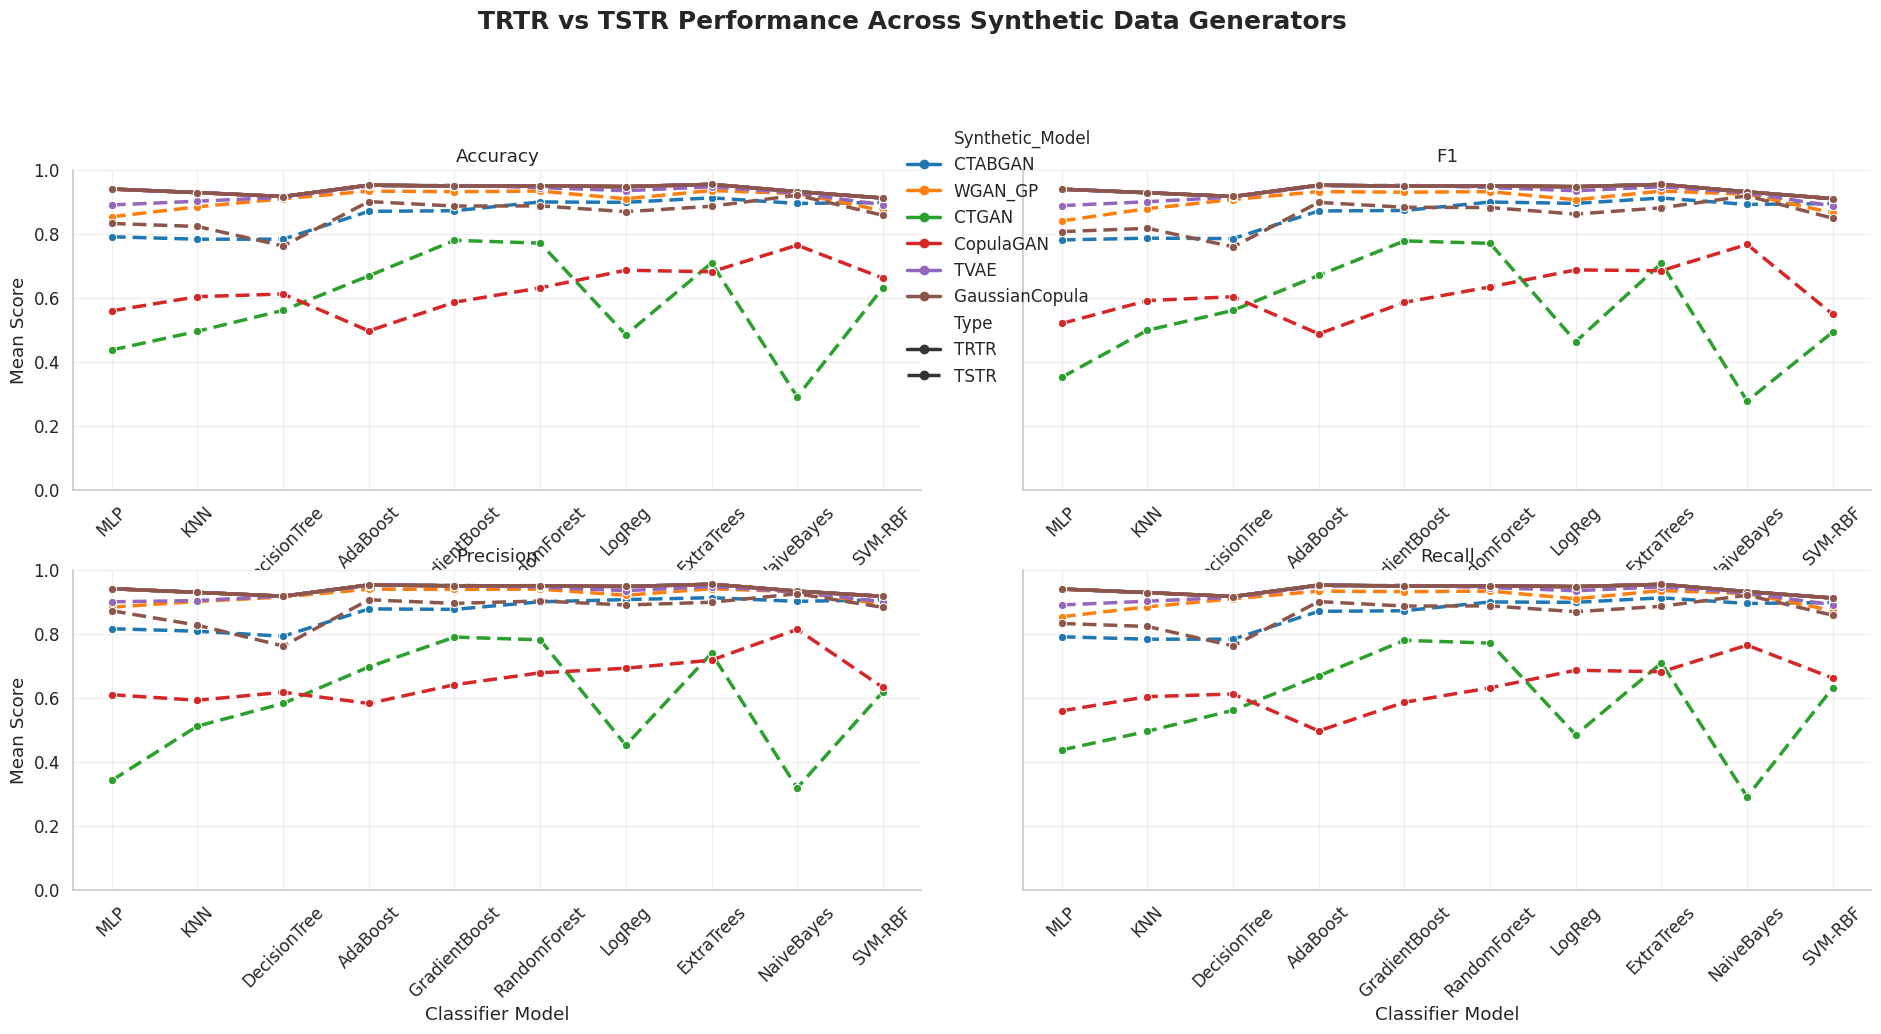

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

metrics = ['Accuracy', 'F1', 'Precision', 'Recall']

plot_rows = []

for _, row in final_comparison_df.iterrows():

    for metric in metrics:

        plot_rows.append({
            'Synthetic_Model': row['Synthetic_Model'],
            'Classifier_Model': row['Model'],
            'Metric': metric,
            'Type': 'TRTR',
            'Score': row[f'{metric} Mean_TRTR']
        })

        plot_rows.append({
            'Synthetic_Model': row['Synthetic_Model'],
            'Classifier_Model': row['Model'],
            'Metric': metric,
            'Type': 'TSTR',
            'Score': row[f'{metric} Mean_TSTR']
        })

plot_df = pd.DataFrame(plot_rows)

generator_order = [
    'CTABGAN',
    'WGAN_GP',
    'CTGAN',
    'CopulaGAN',
    'TVAE',
    'GaussianCopula'
]

palette = {
    'CTABGAN': '#1f77b4',
    'WGAN_GP': '#ff7f0e',
    'CTGAN': '#2ca02c',
    'CopulaGAN': '#d62728',
    'TVAE': '#9467bd',
    'GaussianCopula': '#8c564b'
}

sns.set_theme(style="whitegrid", font_scale=1.1)

g = sns.relplot(
    data=plot_df,
    x='Classifier_Model',
    y='Score',
    col='Metric',
    col_wrap=2,
    hue='Synthetic_Model',
    hue_order=generator_order,
    style='Type',
    dashes={
        'TRTR': '',
        'TSTR': (4, 2)
    },
    palette=palette,
    kind='line',
    marker='o',
    linewidth=2.5,
    height=5,
    aspect=1.8,
    errorbar=None,
    facet_kws={
        'sharex': False,
        'sharey': True
    }
)

g.set_axis_labels("Classifier Model", "Mean Score")
g.set_titles("{col_name}")

for i, ax in enumerate(g.axes.flat):

    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    if i % 2 == 1:
        ax.set_ylabel("")
        ax.tick_params(axis='y', left=False)

g.fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.82,
    bottom=0.10,
    wspace=0.12,
    hspace=0.25
)

g.fig.suptitle(
    "TRTR vs TSTR Performance Across Synthetic Data Generators",
    fontsize=18,
    fontweight='bold',
    y=0.98
)

legend = g._legend
legend.set_title(None)
legend.set_bbox_to_anchor((0.5, 0.92))
legend._loc = 9

try:
    legend.set_ncols(6)
except:
    legend._ncols = 6

plt.show()